In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
import os

PROJECT = "/content/drive/MyDrive/Colab Notebooks"
RUN_DIR = os.path.join(PROJECT, "runs")

os.makedirs(RUN_DIR, exist_ok=True)

print("Project folder:", RUN_DIR)

Project folder: /content/drive/MyDrive/Colab Notebooks/runs


In [10]:
ckpt_path = os.path.join(RUN_DIR, "ckpt_mnist_5epoch.pt")

torch.save({
    "model": model.state_dict()
}, ckpt_path)

print("Checkpoint saved to:", ckpt_path)

Checkpoint saved to: /content/drive/MyDrive/Colab Notebooks/runs/ckpt_mnist_5epoch.pt


In [11]:
opt = torch.optim.AdamW(model.parameters(), lr=2e-4)

In [12]:
ckpt_path = os.path.join(RUN_DIR, "ckpt_mnist_5epoch.pt")

ckpt = torch.load(ckpt_path, map_location=device)

model.load_state_dict(ckpt["model"])
model.eval()

print("Checkpoint loaded successfully")

Checkpoint loaded successfully


In [13]:
RUN_DIR = "/content/drive/MyDrive/Colab Notebooks/demo"

In [14]:
import time
import os
import torch
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from torchvision.utils import make_grid, save_image

@torch.no_grad()
def sample_ddpm(model, diff, n=16):
    model.eval()
    x = torch.randn(n, 1, 32, 32, device=device)

    for i in tqdm(range(diff.T - 1, -1, -1), desc=f"DDPM {diff.T} steps"):
        t = torch.full((n,), i, device=device, dtype=torch.long)
        eps = model(x, t)

        beta = diff.betas[t].view(-1, 1, 1, 1)
        alpha = diff.alphas[t].view(-1, 1, 1, 1)
        alpha_bar = diff.alphas_bar[t].view(-1, 1, 1, 1)

        mean = (1 / torch.sqrt(alpha)) * (x - (beta / torch.sqrt(1 - alpha_bar)) * eps)

        if i > 0:
            x = mean + torch.sqrt(beta) * torch.randn_like(x)
        else:
            x = mean

    x = (x.clamp(-1, 1) + 1) / 2
    return x


@torch.no_grad()
def sample_ddim(model, diff, n=16, ddim_steps=50, eta=0.0):
    model.eval()
    x = torch.randn(n, 1, 32, 32, device=device)

    step_indices = torch.linspace(diff.T - 1, 0, ddim_steps, dtype=torch.long, device=device)

    for i in tqdm(range(len(step_indices)), desc=f"DDIM {ddim_steps} steps"):
        t = step_indices[i]
        t_batch = torch.full((n,), t, device=device, dtype=torch.long)

        eps = model(x, t_batch)

        alpha_bar_t = diff.alphas_bar[t]

        if i == len(step_indices) - 1:
            alpha_bar_prev = torch.tensor(1.0, device=device)
        else:
            t_prev = step_indices[i + 1]
            alpha_bar_prev = diff.alphas_bar[t_prev]

        alpha_bar_t = alpha_bar_t.view(1, 1, 1, 1)
        alpha_bar_prev = alpha_bar_prev.view(1, 1, 1, 1)

        x0_pred = (x - torch.sqrt(1 - alpha_bar_t) * eps) / torch.sqrt(alpha_bar_t)
        x0_pred = x0_pred.clamp(-1, 1)

        sigma = eta * torch.sqrt((1 - alpha_bar_prev) / (1 - alpha_bar_t)) * torch.sqrt(
            torch.clamp(1 - alpha_bar_t / alpha_bar_prev, min=0.0)
        )

        noise = torch.randn_like(x) if eta > 0 else torch.zeros_like(x)
        dir_xt = torch.sqrt(torch.clamp(1 - alpha_bar_prev - sigma**2, min=0.0)) * eps

        x = torch.sqrt(alpha_bar_prev) * x0_pred + dir_xt + sigma * noise

    x = (x.clamp(-1, 1) + 1) / 2
    return x

### DDPM and DDIM Sampling
This cell defines standard DDPM sampling and faster DDIM sampling for comparing image generation speed and quality.

In [16]:
import os

RUN_DIR = "/content/drive/MyDrive/Colab Notebooks/demo"

os.makedirs(RUN_DIR, exist_ok=True)

print("Folder ready:", RUN_DIR)

Folder ready: /content/drive/MyDrive/Colab Notebooks/demo


In [17]:
ddpm_path = os.path.join(RUN_DIR, "ddpm_300steps.png")
save_image(make_grid(samples_ddpm, nrow=4), ddpm_path)

In [18]:
import os

RUN_DIR = "/content/drive/MyDrive/Colab Notebooks"

os.makedirs(RUN_DIR, exist_ok=True)

print("Saving results to:", RUN_DIR)

Saving results to: /content/drive/MyDrive/Colab Notebooks


In [19]:
from google.colab import drive
drive.mount('/content/drive')

import os

RUN_DIR = "/content/drive/MyDrive/Colab Notebooks/CSE499B_results"
os.makedirs(RUN_DIR, exist_ok=True)

print("Saving results to:", RUN_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saving results to: /content/drive/MyDrive/Colab Notebooks/CSE499B_results


In [20]:
from google.colab import drive
drive.mount('/content/drive')

import os

RUN_DIR = "/content/drive/MyDrive/Colab Notebooks/CSE499B_results"
os.makedirs(RUN_DIR, exist_ok=True)

print("Saving results to:", RUN_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saving results to: /content/drive/MyDrive/Colab Notebooks/CSE499B_results


### Required Libraries
This cell imports the required libraries for loading the model, sampling images, visualization, and saving reports.

In [21]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

class Diffusion:
    def __init__(self, T=300, beta_start=1e-4, beta_end=2e-2):
        self.T = T
        self.betas = torch.linspace(beta_start, beta_end, T).to(device)
        self.alphas = 1.0 - self.betas
        self.alphas_bar = torch.cumprod(self.alphas, dim=0)

        self.sqrt_ab = torch.sqrt(self.alphas_bar)
        self.sqrt_1mab = torch.sqrt(1 - self.alphas_bar)

    def sample_timesteps(self, n):
        return torch.randint(0, self.T, (n,), device=device)

    def q_sample(self, x0, t, noise=None):
        if noise is None:
            noise = torch.randn_like(x0)
        a = self.sqrt_ab[t].view(-1, 1, 1, 1)
        b = self.sqrt_1mab[t].view(-1, 1, 1, 1)
        return a * x0 + b * noise, noise

diff = Diffusion(T=300)

device: cuda


### Diffusion Setup
This cell defines the diffusion schedule and helper functions used in DDPM and DDIM sampling.

In [22]:
def time_embedding(t, dim=128):
    half = dim // 2
    freqs = torch.exp(-math.log(10000) * torch.arange(0, half, device=t.device) / (half - 1))
    args = t[:, None].float() * freqs[None]
    return torch.cat([torch.sin(args), torch.cos(args)], dim=-1)

class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, tdim):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.time = nn.Linear(tdim, out_ch)
        self.skip = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
        self.gn1 = nn.GroupNorm(8, out_ch)
        self.gn2 = nn.GroupNorm(8, out_ch)

    def forward(self, x, t_emb):
        h = F.silu(self.gn1(self.conv1(x)))
        h = h + self.time(t_emb).view(t_emb.size(0), -1, 1, 1)
        h = F.silu(self.gn2(self.conv2(h)))
        return h + self.skip(x)

class UNetSmall(nn.Module):
    def __init__(self, in_ch=1, base=64, tdim=128):
        super().__init__()
        self.tdim = tdim
        self.tmlp = nn.Sequential(
            nn.Linear(tdim, tdim),
            nn.SiLU(),
            nn.Linear(tdim, tdim)
        )

        self.inp = nn.Conv2d(in_ch, base, 3, padding=1)

        self.rb1 = ResBlock(base, base, tdim)
        self.down1 = nn.MaxPool2d(2)

        self.rb2 = ResBlock(base, base * 2, tdim)
        self.down2 = nn.MaxPool2d(2)

        self.mid = ResBlock(base * 2, base * 2, tdim)

        self.up1 = nn.Upsample(scale_factor=2, mode="nearest")
        self.rb3 = ResBlock(base * 2 + base * 2, base, tdim)

        self.up2 = nn.Upsample(scale_factor=2, mode="nearest")
        self.rb4 = ResBlock(base + base, base, tdim)

        self.out = nn.Conv2d(base, in_ch, 1)

    def forward(self, x, t):
        t_emb = self.tmlp(time_embedding(t, self.tdim))

        x1 = self.inp(x)
        x1 = self.rb1(x1, t_emb)
        x2 = self.down1(x1)

        x2 = self.rb2(x2, t_emb)
        x3 = self.down2(x2)

        x3 = self.mid(x3, t_emb)

        u1 = self.up1(x3)
        u1 = torch.cat([u1, x2], dim=1)
        u1 = self.rb3(u1, t_emb)

        u2 = self.up2(u1)
        u2 = torch.cat([u2, x1], dim=1)
        u2 = self.rb4(u2, t_emb)

        return self.out(u2)

### U-Net Model
This cell defines the lightweight U-Net architecture used for noise prediction during reverse diffusion.

In [23]:
model = UNetSmall(in_ch=1, base=64, tdim=128).to(device)

ckpt_path = os.path.join(RUN_DIR, "ckpt_mnist_5epoch.pt")
ckpt = torch.load(ckpt_path, map_location=device)

model.load_state_dict(ckpt["model"])
model.eval()

print("Checkpoint loaded from:", ckpt_path)

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Colab Notebooks/CSE499B_results/ckpt_mnist_5epoch.pt'

In [24]:
import os

RUN_DIR = "/content/drive/MyDrive/Colab Notebooks/CSE499B_results"
os.makedirs(RUN_DIR, exist_ok=True)

print("RUN_DIR:", RUN_DIR)
print("Files:", os.listdir(RUN_DIR))

RUN_DIR: /content/drive/MyDrive/Colab Notebooks/CSE499B_results
Files: []


In [25]:
import os
import torch

RUN_DIR = "/content/drive/MyDrive/Colab Notebooks/CSE499B_results"
os.makedirs(RUN_DIR, exist_ok=True)

ckpt_path = os.path.join(RUN_DIR, "ckpt_mnist_5epoch.pt")

torch.save({
    "model": model.state_dict()
}, ckpt_path)

print("Checkpoint saved to:", ckpt_path)
print("Files now:", os.listdir(RUN_DIR))

Checkpoint saved to: /content/drive/MyDrive/Colab Notebooks/CSE499B_results/ckpt_mnist_5epoch.pt
Files now: ['ckpt_mnist_5epoch.pt']


In [26]:
model = UNetSmall(in_ch=1, base=64, tdim=128).to(device)

ckpt_path = os.path.join(RUN_DIR, "ckpt_mnist_5epoch.pt")
ckpt = torch.load(ckpt_path, map_location=device)

model.load_state_dict(ckpt["model"])
model.eval()

print("Checkpoint loaded from:", ckpt_path)

Checkpoint loaded from: /content/drive/MyDrive/Colab Notebooks/CSE499B_results/ckpt_mnist_5epoch.pt


In [28]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.Resize(32),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True,
    num_workers=2
)

print("Dataset loaded. Total images:", len(train_dataset))

100%|██████████| 9.91M/9.91M [00:00<00:00, 19.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 484kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.51MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.89MB/s]

Dataset loaded. Total images: 60000


In [29]:
EPOCHS = 5

model.train()

for ep in range(EPOCHS):

    pbar = tqdm(train_loader, desc=f"train epoch {ep+1}/{EPOCHS}")

    for x, _ in pbar:

        x = x.to(device)

        t = diff.sample_timesteps(x.size(0))
        x_t, noise = diff.q_sample(x, t)

        pred = model(x_t, t)

        loss = F.mse_loss(pred, noise)

        opt.zero_grad(set_to_none=True)
        loss.backward()
        opt.step()

        pbar.set_postfix(loss=float(loss.item()))

train epoch 1/5:   0%|          | 0/469 [00:00<?, ?it/s]

train epoch 2/5:   0%|          | 0/469 [00:00<?, ?it/s]

train epoch 3/5:   0%|          | 0/469 [00:00<?, ?it/s]

train epoch 4/5:   0%|          | 0/469 [00:00<?, ?it/s]

train epoch 5/5:   0%|          | 0/469 [00:00<?, ?it/s]

In [30]:
ckpt_path = os.path.join(RUN_DIR, "ckpt_mnist_5epoch.pt")

torch.save({
    "model": model.state_dict()
}, ckpt_path)

print("Checkpoint saved to:", ckpt_path)

Checkpoint saved to: /content/drive/MyDrive/Colab Notebooks/CSE499B_results/ckpt_mnist_5epoch.pt


In [31]:
model = UNetSmall(in_ch=1, base=64, tdim=128).to(device)

ckpt_path = os.path.join(RUN_DIR, "ckpt_mnist_5epoch.pt")
ckpt = torch.load(ckpt_path, map_location=device)

model.load_state_dict(ckpt["model"])
model.eval()

print("Checkpoint loaded from:", ckpt_path)

Checkpoint loaded from: /content/drive/MyDrive/Colab Notebooks/CSE499B_results/ckpt_mnist_5epoch.pt


In [32]:
@torch.no_grad()
def sample_ddpm(model, diff, n=16):
    model.eval()
    x = torch.randn(n, 1, 32, 32, device=device)

    for i in range(diff.T - 1, -1, -1):
        t = torch.full((n,), i, device=device, dtype=torch.long)
        eps = model(x, t)

        beta = diff.betas[t].view(-1, 1, 1, 1)
        alpha = diff.alphas[t].view(-1, 1, 1, 1)
        alpha_bar = diff.alphas_bar[t].view(-1, 1, 1, 1)

        mean = (1 / torch.sqrt(alpha)) * (x - (beta / torch.sqrt(1 - alpha_bar)) * eps)

        if i > 0:
            x = mean + torch.sqrt(beta) * torch.randn_like(x)
        else:
            x = mean

    x = (x.clamp(-1, 1) + 1) / 2
    return x

In [33]:
@torch.no_grad()
def sample_ddim(model, diff, n=16, ddim_steps=50, eta=0.0):
    model.eval()
    x = torch.randn(n, 1, 32, 32, device=device)

    step_indices = torch.linspace(diff.T - 1, 0, ddim_steps, dtype=torch.long, device=device)

    for i in range(len(step_indices)):
        t = step_indices[i]
        t_batch = torch.full((n,), t, device=device, dtype=torch.long)

        eps = model(x, t_batch)

        alpha_bar_t = diff.alphas_bar[t]

        if i == len(step_indices) - 1:
            alpha_bar_prev = torch.tensor(1.0, device=device)
        else:
            t_prev = step_indices[i + 1]
            alpha_bar_prev = diff.alphas_bar[t_prev]

        alpha_bar_t = alpha_bar_t.view(1, 1, 1, 1)
        alpha_bar_prev = alpha_bar_prev.view(1, 1, 1, 1)

        x0_pred = (x - torch.sqrt(1 - alpha_bar_t) * eps) / torch.sqrt(alpha_bar_t)
        x0_pred = x0_pred.clamp(-1, 1)

        sigma = eta * torch.sqrt((1 - alpha_bar_prev) / (1 - alpha_bar_t)) * torch.sqrt(
            torch.clamp(1 - alpha_bar_t / alpha_bar_prev, min=0.0)
        )

        noise = torch.randn_like(x) if eta > 0 else torch.zeros_like(x)
        dir_xt = torch.sqrt(torch.clamp(1 - alpha_bar_prev - sigma**2, min=0.0)) * eps

        x = torch.sqrt(alpha_bar_prev) * x0_pred + dir_xt + sigma * noise

    x = (x.clamp(-1, 1) + 1) / 2
    return x

In [35]:
import time
from torchvision.utils import make_grid, save_image

results = []

start = time.time()
samples_ddpm = sample_ddpm(model, diff, n=16)
ddpm_time = time.time() - start

ddpm_path = os.path.join(RUN_DIR, "ddpm_300steps.png")
save_image(make_grid(samples_ddpm, nrow=4), ddpm_path)

results.append({"method": "DDPM", "steps": 300, "time_sec": ddpm_time, "image_path": ddpm_path})

for steps in [100, 50, 20]:
    start = time.time()
    samples_ddim = sample_ddim(model, diff, n=16, ddim_steps=steps, eta=0.0)
    ddim_time = time.time() - start

    out_path = os.path.join(RUN_DIR, f"ddim_{steps}steps.png")
    save_image(make_grid(samples_ddim, nrow=4), out_path)

    results.append({"method": "DDIM", "steps": steps, "time_sec": ddim_time, "image_path": out_path})

print(results)

[{'method': 'DDPM', 'steps': 300, 'time_sec': 1.0443534851074219, 'image_path': '/content/drive/MyDrive/Colab Notebooks/CSE499B_results/ddpm_300steps.png'}, {'method': 'DDIM', 'steps': 100, 'time_sec': 0.3934457302093506, 'image_path': '/content/drive/MyDrive/Colab Notebooks/CSE499B_results/ddim_100steps.png'}, {'method': 'DDIM', 'steps': 50, 'time_sec': 0.1960618495941162, 'image_path': '/content/drive/MyDrive/Colab Notebooks/CSE499B_results/ddim_50steps.png'}, {'method': 'DDIM', 'steps': 20, 'time_sec': 0.07896661758422852, 'image_path': '/content/drive/MyDrive/Colab Notebooks/CSE499B_results/ddim_20steps.png'}]


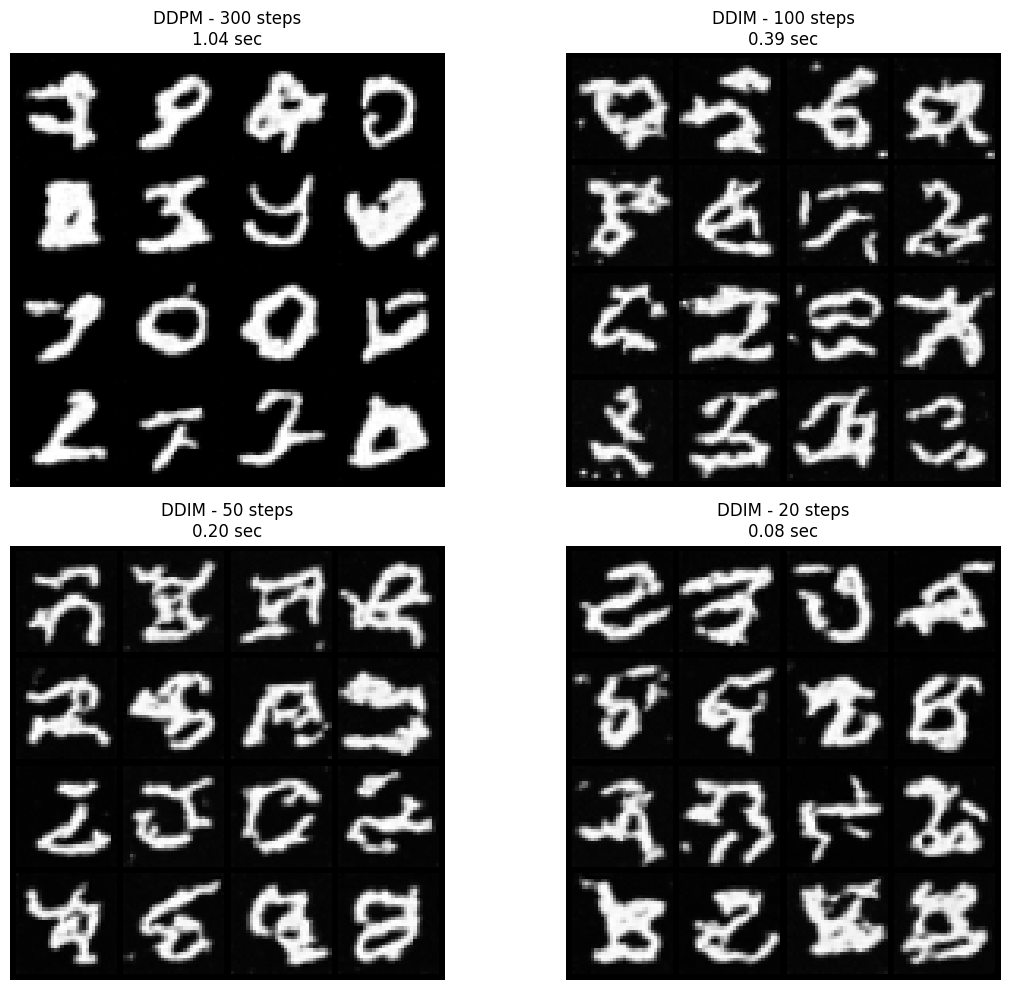

In [36]:
import matplotlib.pyplot as plt
from PIL import Image

plt.figure(figsize=(12, 10))

for idx, row in enumerate(results):
    img = Image.open(row["image_path"])
    plt.subplot(2, 2, idx + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"{row['method']} - {row['steps']} steps\n{row['time_sec']:.2f} sec")

plt.tight_layout()
plt.show()

In [37]:
import pandas as pd

df_compare = pd.DataFrame(results)
csv_path = os.path.join(RUN_DIR, "ddpm_vs_ddim_comparison.csv")
df_compare.to_csv(csv_path, index=False)

display(df_compare)
print("Saved CSV:", csv_path)

,method,steps,time_sec,image_path
0,DDPM,300,1.044353,/content/drive/MyDrive/Colab Notebooks/CSE499B...
1,DDIM,100,0.393446,/content/drive/MyDrive/Colab Notebooks/CSE499B...
2,DDIM,50,0.196062,/content/drive/MyDrive/Colab Notebooks/CSE499B...
3,DDIM,20,0.078967,/content/drive/MyDrive/Colab Notebooks/CSE499B...


Saved CSV: /content/drive/MyDrive/Colab Notebooks/CSE499B_results/ddpm_vs_ddim_comparison.csv


### Conclusion

In this experiment, a diffusion model was trained on the MNIST dataset and evaluated using different sampling strategies.  
The standard DDPM sampling used the full reverse diffusion process with 300 steps and produced stable digit images.  
To improve generation efficiency, DDIM sampling was tested with fewer steps such as 100, 50, and 20.  
The results show that reducing the number of sampling steps significantly decreases generation time.  
DDIM with 100 steps produced images similar to DDPM while being much faster.  
However, using very small step sizes like 20 introduced slightly more noise in the generated digits.  
This demonstrates the efficiency–quality trade-off in diffusion models.  
Overall, DDIM provides a practical way to accelerate image generation while maintaining acceptable visual quality.